In [1]:
%pip install missingno
%pip install xgboost


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, mean_absolute_error,
                              mean_squared_error, r2_score)
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')


In [3]:
# Load from saved files
df_clean = pd.read_csv("data/processed/analysis_ready.csv")
print(df_clean.shape)

(7412, 17)


In [4]:
# Schema Validation — Final analysis_ready.csv
print("=" * 60)
print("      SCHEMA VALIDATION — analysis_ready.csv")
print("=" * 60)

schema = pd.DataFrame({
    'Column': df_clean.columns,
    'Dtype': df_clean.dtypes.values,
    'Non_Null': df_clean.notnull().sum().values,
    'Null': df_clean.isnull().sum().values,
    'Null_%': (df_clean.isnull().sum().values / len(df_clean) * 100).round(2),
    'Sample_Value': [df_clean[col].dropna().iloc[0] if df_clean[col].notna().any() else 'N/A' for col in df_clean.columns]
})

print(schema.to_string(index=False))
print("=" * 60)
print(f"Total columns : {len(df_clean.columns)}")
print(f"Total rows    : {len(df_clean):,}")
print(f"Zero nulls    : {df_clean.isnull().sum().sum() == 0}")

      SCHEMA VALIDATION — analysis_ready.csv
                  Column   Dtype  Non_Null  Null  Null_% Sample_Value
                 country     str      7412     0     0.0  Afghanistan
            country_code     str      7412     0     0.0          AFG
                    year   int64      7412     0     0.0         1990
      electricity_access float64      7412     0     0.0          4.4
          gdp_per_capita float64      7412     0     0.0   174.930991
urban_population_percent float64      7412     0     0.0    17.264035
rural_population_percent float64      7412     0     0.0    82.735965
      population_density float64      7412     0     0.0    18.468424
        total_population float64      7412     0     0.0   12045660.0
renewable_energy_percent float64      7412     0     0.0         23.0
government_effectiveness float64      7412     0     0.0    -2.175167
           risk_category     str      7412     0     0.0       Severe
      elec_access_change float64      7412   

# Train / Validation / Test Split

In [5]:
# Final check on year range and country coverage before modeling

print("=== Filter to 1990–2023 ===\n")

df_model = df_clean[
    (df_clean['year'] >= 1990) & (df_clean['year'] <= 2023)
].copy().reset_index(drop=True)

print(f"Original shape : {df_clean.shape}")
print(f"Filtered shape : {df_model.shape}")
print(f"Year range     : {int(df_model['year'].min())}–{int(df_model['year'].max())}")
print(f"Countries      : {df_model['country'].nunique()}")

=== Filter to 1990–2023 ===

Original shape : (7412, 17)
Filtered shape : (7412, 17)
Year range     : 1990–2023
Countries      : 218


In [6]:
#  80/10/10 Temporal Split 
# Train    : 1990–2017  (~80%) — model learns from historical data
# Validate : 2018–2020  (~10%) — tune model hyperparameters
# Test     : 2021–2023  (~10%) — final accuracy check, simulate forecast
# Forecast : 2024–2027         — true future, no actuals available yet

train_df = df_model[df_model['year'] <= 2017].copy().reset_index(drop=True)
val_df   = df_model[(df_model['year'] >= 2018) & (df_model['year'] <= 2020)].copy().reset_index(drop=True)
test_df  = df_model[df_model['year'] >= 2021].copy().reset_index(drop=True)

print("=== 80/10/10 Temporal Split ===\n")
print(f"{'Set':<12} {'Years':<15} {'Rows':>8} {'%':>8}")
print("-" * 45)
print(f"{'Train':<12} {'1990–2017':<15} {len(train_df):>8,} {len(train_df)/len(df_model)*100:>7.1f}%")
print(f"{'Validate':<12} {'2018–2020':<15} {len(val_df):>8,} {len(val_df)/len(df_model)*100:>7.1f}%")
print(f"{'Test':<12} {'2021–2023':<15} {len(test_df):>8,} {len(test_df)/len(df_model)*100:>7.1f}%")
print("-" * 45)
print(f"{'Total':<12} {'1990–2023':<15} {len(df_model):>8,} {'100.0%':>8}")
print(f"\nForecast target : 2024–2027 (true future, no actuals available)")

=== 80/10/10 Temporal Split ===

Set          Years               Rows        %
---------------------------------------------
Train        1990–2017          6,104    82.4%
Validate     2018–2020            654     8.8%
Test         2021–2023            654     8.8%
---------------------------------------------
Total        1990–2023          7,412   100.0%

Forecast target : 2024–2027 (true future, no actuals available)


In [7]:
# Check class balance across sets to ensure no major distribution shifts

print("=== Class Balance Across All Three Sets ===\n")

order = ['Severe', 'Moderate', 'Minimal']

print(f"{'Category':<12} {'Train':>8} {'Train%':>8} {'Val':>8} {'Val%':>8} {'Test':>8} {'Test%':>8}")
print("-" * 65)

for cat in order:
    tc = train_df['risk_category'].value_counts().get(cat, 0)
    tp = train_df['risk_category'].value_counts(normalize=True).get(cat, 0) * 100
    vc = val_df['risk_category'].value_counts().get(cat, 0)
    vp = val_df['risk_category'].value_counts(normalize=True).get(cat, 0) * 100
    sc = test_df['risk_category'].value_counts().get(cat, 0)
    sp = test_df['risk_category'].value_counts(normalize=True).get(cat, 0) * 100
    print(f"  {cat:<10} {tc:>8,} {tp:>7.1f}% {vc:>8,} {vp:>7.1f}% {sc:>8,} {sp:>7.1f}%")

print("-" * 65)
print(f"  {'Total':<10} {len(train_df):>8,} {'100.0%':>8} {len(val_df):>8,} {'100.0%':>8} {len(test_df):>8,} {'100.0%':>8}")

=== Class Balance Across All Three Sets ===

Category        Train   Train%      Val     Val%     Test    Test%
-----------------------------------------------------------------
  Severe        1,386    22.7%       85    13.0%       63     9.6%
  Moderate      1,057    17.3%       95    14.5%      112    17.1%
  Minimal       3,661    60.0%      474    72.5%      479    73.2%
-----------------------------------------------------------------
  Total         6,104   100.0%      654   100.0%      654   100.0%


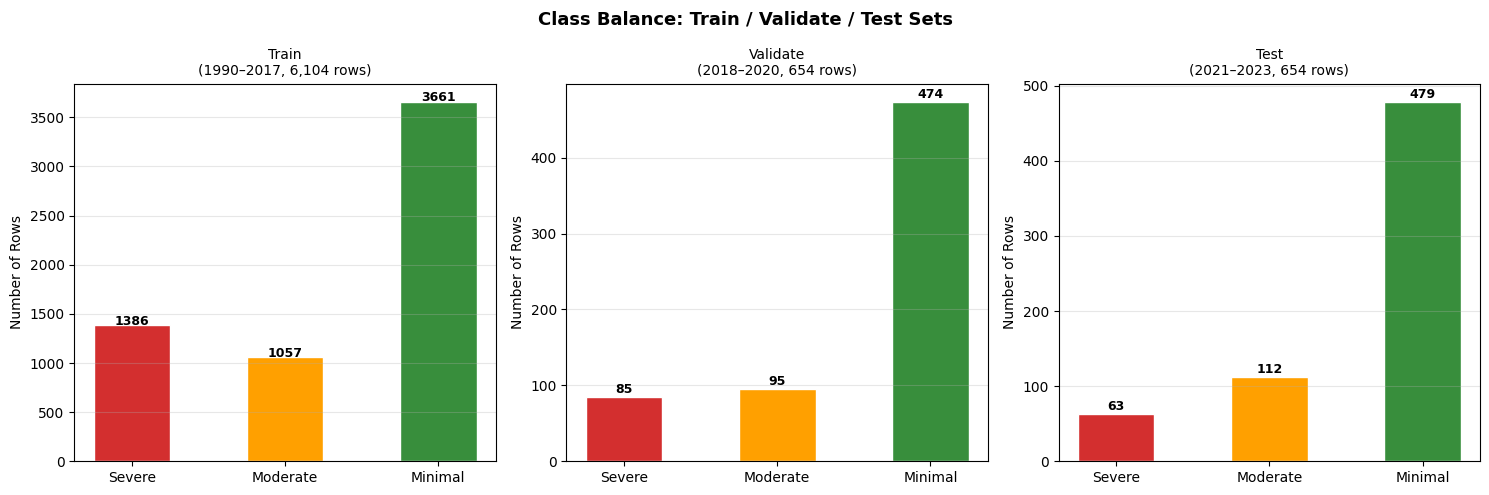

In [8]:
# Visualize class balance across sets

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Class Balance: Train / Validate / Test Sets",
             fontsize=13, fontweight='bold')

colors   = ['#D32F2F', '#FFA000', '#388E3C']
datasets = [
    (train_df, f"Train\n(1990–2017, {len(train_df):,} rows)"),
    (val_df,   f"Validate\n(2018–2020, {len(val_df):,} rows)"),
    (test_df,  f"Test\n(2021–2023, {len(test_df):,} rows)"),
]

for ax, (data, title) in zip(axes, datasets):
    counts = data['risk_category'].value_counts()
    vals   = [counts.get(c, 0) for c in order]
    bars   = ax.bar(order, vals, color=colors, edgecolor='white', width=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("Number of Rows")
    ax.grid(True, axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                str(v), ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

In [9]:
# Verify No overlap of years between sets

print("=== Split Integrity Check ===\n")

train_years = set(train_df['year'].unique())
val_years   = set(val_df['year'].unique())
test_years  = set(test_df['year'].unique())

print(f"Train years    : {min(train_years)}–{max(train_years)}")
print(f"Validate years : {min(val_years)}–{max(val_years)}")
print(f"Test years     : {min(test_years)}–{max(test_years)}")

overlap_tv = train_years & val_years
overlap_vt = val_years   & test_years
overlap_tt = train_years & test_years

print(f"\nTrain ∩ Validate : {overlap_tv}  (should be empty)")
print(f"Validate ∩ Test  : {overlap_vt}  (should be empty)")
print(f"Train ∩ Test     : {overlap_tt}  (should be empty)")

total_check = len(train_df) + len(val_df) + len(test_df)
print(f"\nTrain + Val + Test : {total_check:,}")
print(f"Total df_model     : {len(df_model):,}")
print(f"Counts match       : {total_check == len(df_model)}")

print("\nNo overlap between any sets." if not overlap_tv and not overlap_vt and not overlap_tt
      else "\nOverlap detected — check split logic.")

=== Split Integrity Check ===

Train years    : 1990–2017
Validate years : 2018–2020
Test years     : 2021–2023

Train ∩ Validate : set()  (should be empty)
Validate ∩ Test  : set()  (should be empty)
Train ∩ Test     : set()  (should be empty)

Train + Val + Test : 7,412
Total df_model     : 7,412
Counts match       : True

No overlap between any sets.


In [10]:
# Save the three sets to CSV files for modeling

os.makedirs("data/processed", exist_ok=True)

train_df.to_csv("data/processed/train_data.csv",      index=False)
val_df.to_csv("data/processed/validation_data.csv",   index=False)
test_df.to_csv("data/processed/test_data.csv",        index=False)

print("=== Files Saved to data/processed/ ===\n")
print(f"train_data.csv      : 1990–2017  {len(train_df):,} rows  ({len(train_df)/len(df_clean)*100:.1f}%)")
print(f"validation_data.csv : 2018–2020  {len(val_df):,} rows    ({len(val_df)/len(df_clean)*100:.1f}%)")
print(f"test_data.csv       : 2021–2023  {len(test_df):,} rows    ({len(test_df)/len(df_clean)*100:.1f}%)")

=== Files Saved to data/processed/ ===

train_data.csv      : 1990–2017  6,104 rows  (82.4%)
validation_data.csv : 2018–2020  654 rows    (8.8%)
test_data.csv       : 2021–2023  654 rows    (8.8%)


## Modelling

In [11]:
# Features used for both classification and regression
FEATURES = [
    'gdp_per_capita', 'urban_population_percent', 'rural_population_percent',
    'population_density', 'total_population', 'renewable_energy_percent',
    'government_effectiveness', 'elec_access_change', 'gdp_growth',
    'urban_change', 'lagged_electricity', 'lagged_gdp'
]

CLASS_TARGET = 'risk_category'
REG_TARGET   = 'electricity_access'

# Encode class labels
le = LabelEncoder()
le.fit(['Severe', 'Moderate', 'Minimal'])

X_train = train_df[FEATURES]
X_val   = val_df[FEATURES]
X_test  = test_df[FEATURES]

# Classification targets
y_train_cls = le.transform(train_df[CLASS_TARGET])
y_val_cls   = le.transform(val_df[CLASS_TARGET])
y_test_cls  = le.transform(test_df[CLASS_TARGET])

# Regression targets
y_train_reg = train_df[REG_TARGET]
y_val_reg   = val_df[REG_TARGET]
y_test_reg  = test_df[REG_TARGET]

print(f"X_train : {X_train.shape}")
print(f"X_val   : {X_val.shape}")
print(f"X_test  : {X_test.shape}")
print(f"Classes : {le.classes_}")

X_train : (6104, 12)
X_val   : (654, 12)
X_test  : (654, 12)
Classes : ['Minimal' 'Moderate' 'Severe']


In [12]:
def eval_classifier(model, X, y_true, label=""):
    y_pred = model.predict(X)
    acc = accuracy_score(y_true, y_pred)
    print(f"\n{'='*50}")
    print(f"  {label} — Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred, target_names=le.classes_))
    return y_pred, acc

def eval_regressor(model, X, y_true, label=""):
    y_pred = model.predict(X)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"{'='*50}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  R²   : {r2:.4f}")
    return y_pred, mae, rmse, r2

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title(title, fontweight='bold')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

# Part 1 — Classification (Predict Risk Category)
## Baseline: Random Forest Classifier

--- Validation ---

  RF Classifier (Baseline) — Val — Accuracy: 0.9725
              precision    recall  f1-score   support

     Minimal       1.00      0.98      0.99       474
    Moderate       0.89      0.93      0.91        95
      Severe       0.93      0.96      0.95        85

    accuracy                           0.97       654
   macro avg       0.94      0.96      0.95       654
weighted avg       0.97      0.97      0.97       654



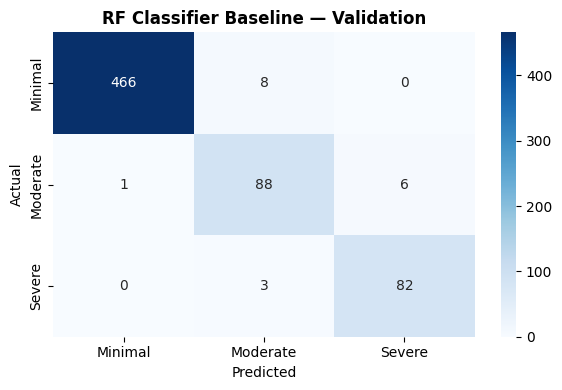

In [13]:
rf_cls_base = RandomForestClassifier(n_estimators=100, random_state=42)
rf_cls_base.fit(X_train, y_train_cls)

print("--- Validation ---")
val_pred_cls_base, val_acc_base = eval_classifier(rf_cls_base, X_val, y_val_cls, "RF Classifier (Baseline) — Val")
plot_confusion(y_val_cls, val_pred_cls_base, "RF Classifier Baseline — Validation")

CV Accuracy (5-fold): 0.9836 ± 0.0014
CV Scores: [0.9844 0.982  0.982  0.9844 0.9852]

--- Validation ---

  RF Classifier (Improved) — Val — Accuracy: 0.9740
              precision    recall  f1-score   support

     Minimal       1.00      0.98      0.99       474
    Moderate       0.89      0.94      0.91        95
      Severe       0.94      0.96      0.95        85

    accuracy                           0.97       654
   macro avg       0.94      0.96      0.95       654
weighted avg       0.97      0.97      0.97       654



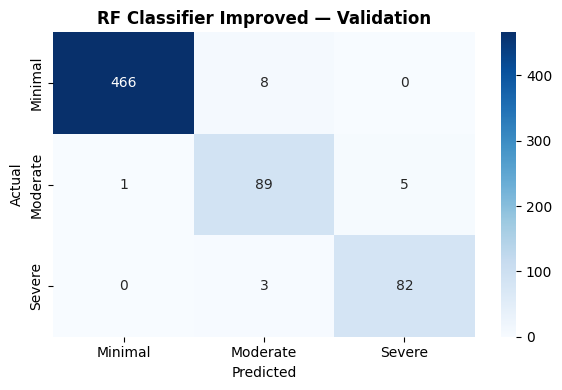

In [14]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Improved model with tuned hyperparameters
rf_cls_improved = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)
rf_cls_improved.fit(X_train, y_train_cls)

# Cross-validation on training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_cls_improved, X_train, y_train_cls, cv=cv, scoring='accuracy')

print(f"CV Accuracy (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"CV Scores: {cv_scores.round(4)}")

print("\n--- Validation ---")
val_pred_cls_imp, val_acc_imp = eval_classifier(rf_cls_improved, X_val, y_val_cls, "RF Classifier (Improved) — Val")
plot_confusion(y_val_cls, val_pred_cls_imp, "RF Classifier Improved — Validation")

XGB CV Accuracy (5-fold): 0.9897 ± 0.0018

--- Validation ---

  XGBoost Classifier — Val — Accuracy: 0.9878
              precision    recall  f1-score   support

     Minimal       1.00      0.99      0.99       474
    Moderate       0.95      0.97      0.96        95
      Severe       0.98      1.00      0.99        85

    accuracy                           0.99       654
   macro avg       0.97      0.99      0.98       654
weighted avg       0.99      0.99      0.99       654



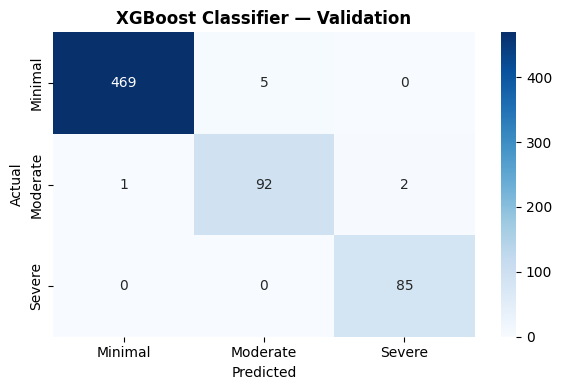

In [15]:
xgb_cls = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)
xgb_cls.fit(X_train, y_train_cls,
            eval_set=[(X_val, y_val_cls)],
            verbose=False)

cv_scores_xgb = cross_val_score(xgb_cls, X_train, y_train_cls, cv=cv, scoring='accuracy')
print(f"XGB CV Accuracy (5-fold): {cv_scores_xgb.mean():.4f} ± {cv_scores_xgb.std():.4f}")

print("\n--- Validation ---")
val_pred_xgb_cls, val_acc_xgb = eval_classifier(xgb_cls, X_val, y_val_cls, "XGBoost Classifier — Val")
plot_confusion(y_val_cls, val_pred_xgb_cls, "XGBoost Classifier — Validation")

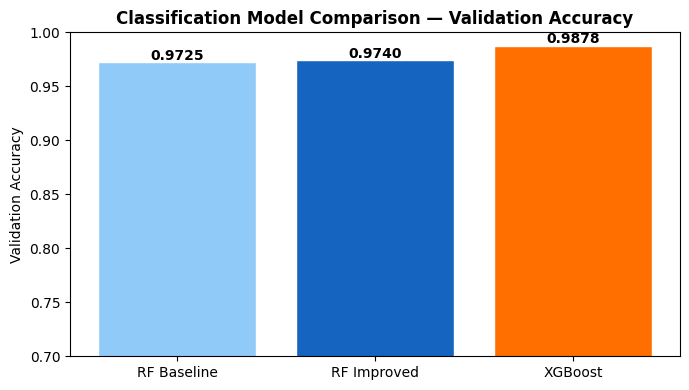

Best classifier: XGBoost (0.9878)


In [16]:
results_cls = {
    'RF Baseline':  accuracy_score(y_val_cls, rf_cls_base.predict(X_val)),
    'RF Improved':  accuracy_score(y_val_cls, rf_cls_improved.predict(X_val)),
    'XGBoost':      accuracy_score(y_val_cls, xgb_cls.predict(X_val)),
}

plt.figure(figsize=(7, 4))
bars = plt.bar(results_cls.keys(), results_cls.values(),
               color=['#90CAF9', '#1565C0', '#FF6F00'], edgecolor='white')
plt.ylim(0.7, 1.0)
plt.ylabel('Validation Accuracy')
plt.title('Classification Model Comparison — Validation Accuracy', fontweight='bold')
for bar, val in zip(bars, results_cls.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{val:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

best_cls_name = max(results_cls, key=results_cls.get)
print(f"Best classifier: {best_cls_name} ({results_cls[best_cls_name]:.4f})")